# Medical and Biomedical Experiments

A trial report asks the same questions in the same order: did the arms differ at the end, how large is the difference and does it grow with the dose, how many subjects reached the target, when did the arms separate, who stayed in the trial, what else moved, and is any of it a safety concern. This page walks one trial through those questions and names the figure that answers each, so the chart to reach for arrives with the question rather than the other way round. Every figure links to the chart guide that covers it in full.

The trial is a **simulated** 12-week, three-arm study of a glucose-lowering compound: 40 subjects each on placebo, a low dose and a high dose, with HbA1c measured at five visits, a panel of eight metabolic markers, four safety labs, and a dropout each time a subject left. It is one seeded numpy draw in a hidden cell, so every docs build produces the same figures, and it stands in for any arm-by-time experiment (a preclinical dose study, a cell assay across conditions, a cohort followed over visits). The tests are `scipy.stats` calls written out in the open; a real protocol would prespecify a covariate-adjusted model in their place.

In [1]:
import numpy as np
from scipy import stats as scipy_stats

from datachart.charts import (
    BarChart,
    BoxPlot,
    DumbbellChart,
    Heatmap,
    LineChart,
    SwarmPlot,
    ViolinPlot,
)
from datachart.constants import (
    EMPHASIS,
    FIG_SIZE,
    LINE_DRAW_STYLE,
    COLOR_NORM,
    SHOW_GRID,
    VALUE_FORMAT,
)
from datachart.utils import Grid, Panel
from datachart.utils.stats import bootstrap_ci

The hidden cell below holds the whole simulation. `subjects` is one dict per subject: one of the `ARMS`, the HbA1c reading at each of the `WEEKS`, the change in ALT by the last visit, and the week the subject dropped out or `None`. `marker_change` holds the percent change from baseline of each of the `MARKERS` per arm, and `safety` the arm means of the four `SAFETY` labs at baseline and week 12. The sections that follow only reshape those into the records the charts take.

In [2]:
# Every number below is simulated: one illustrative 12-week, three-arm trial of
# a glucose-lowering compound, seeded so every docs build draws the same figures.
rng = np.random.default_rng(20260922)

ARMS = ["Placebo", "Low dose", "High dose"]
PER_ARM = 40
WEEKS = [0, 2, 4, 8, 12]

# --- the primary endpoint: HbA1c (%) of every subject at every visit ---
# each arm's mean change from baseline settles towards a floor by week 12
EFFECT = {"Placebo": -0.15, "Low dose": -0.55, "High dose": -1.05}
DROPOUT_RATE = {"Placebo": 0.15, "Low dose": 0.08, "High dose": 0.12}

_weeks = np.array(WEEKS)
_course = 1 - np.exp(-_weeks / 4.0)  # the fraction of the effect reached per visit
_arm = np.repeat(ARMS, PER_ARM)
_baseline = rng.normal(8.1, 0.65, _arm.size)
_response = np.array([EFFECT[arm] for arm in _arm]) + rng.normal(0, 0.28, _arm.size)
_noise = rng.normal(0, 0.12, (_arm.size, _weeks.size))
_hba1c = _baseline[:, None] + _response[:, None] * _course[None, :] + _noise
_hba1c[:, 0] = _baseline

# the week each subject left the trial, or None for the ones who completed it
_hazard = np.array([DROPOUT_RATE[arm] for arm in _arm]) / 12
_leaving = np.ceil(rng.exponential(1 / _hazard))

# the change in ALT (U/L) by week 12: a handful of high-dose subjects spike
ALT_SHIFT = {"Placebo": 0.5, "Low dose": 1.5, "High dose": 4.0}
_alt = np.array([ALT_SHIFT[arm] for arm in _arm]) + rng.normal(0, 4.5, _arm.size)
_spikers = rng.choice(np.flatnonzero(_arm == "High dose"), 4, replace=False)
_alt[_spikers] += rng.uniform(22, 38, _spikers.size)

subjects = [
    {
        "id": f"S{index + 1:03d}",
        "arm": str(arm),
        "hba1c": dict(zip(WEEKS, np.round(row, 2).tolist())),
        "alt_change": round(float(alt), 1),
        "dropout": int(week) if week < 12 else None,
    }
    for index, (arm, row, alt, week) in enumerate(zip(_arm, _hba1c, _alt, _leaving))
]

# --- the secondary panel: percent change from baseline per marker and arm ---
MARKERS = [
    "Fasting glucose",
    "Fasting insulin",
    "HOMA-IR",
    "Triglycerides",
    "LDL cholesterol",
    "HDL cholesterol",
    "Body weight",
    "hs-CRP",
]
_shift = np.array(
    [
        # placebo, low dose, high dose
        [-2.0, -9.0, -17.0],
        [-1.0, -12.0, -24.0],
        [-3.0, -19.0, -36.0],
        [1.0, -8.0, -15.0],
        [0.5, -2.0, -4.0],
        [0.0, 2.5, 5.0],
        [-0.5, -2.0, -3.5],
        [2.0, -10.0, -22.0],
    ]
)
marker_change = {
    marker: dict(zip(ARMS, np.round(row + rng.normal(0, 1.2, 3), 1).tolist()))
    for marker, row in zip(MARKERS, _shift)
}

# --- safety: the arm means of four labs and vitals at baseline and week 12 ---
SAFETY = ["ALT (U/L)", "Creatinine (µmol/L)", "Systolic BP (mmHg)", "Heart rate (bpm)"]
_safety_start = np.array([[27.0, 76.0, 134.0, 74.0]] * 3) + rng.normal(0, 1.0, (3, 4))
_safety_shift = np.array(
    [
        [_alt[_arm == arm].mean(), *rest]
        for arm, rest in zip(
            ARMS, [[0.3, -1.0, 0.2], [0.5, -3.0, 0.8], [1.0, -5.0, 1.5]]
        )
    ]
)
safety = {
    arm: {
        lab: {"baseline": round(float(a), 1), "week 12": round(float(a + b), 1)}
        for lab, a, b in zip(SAFETY, starts, shifts)
    }
    for arm, starts, shifts in zip(ARMS, _safety_start, _safety_shift)
}

## The primary endpoint

### Do the arms differ at the end of the trial?

The first figure of a trial report shows the endpoint itself, per arm, with every subject visible: a test says whether the arms differ, and only the points say whether one outlier or one subgroup is doing the work. A [box plot](../../how-to-guides/charts/boxplot/) gives each arm its median and quartiles, and a [swarm plot](../../how-to-guides/charts/swarmplot/) laid over it in a [Panel](../../how-to-guides/utility/panel/) adds the subjects themselves; the two share their category positions, so the points land on their boxes. The endpoint is the change from baseline at week 12, for the subjects who reached it.

The test is the Kruskal-Wallis H, a rank-based one-way test that asks whether any arm sits apart from the others, chosen over an ANOVA because nothing yet says the changes are normal. A significant omnibus result says only *some* pair differs, so each pair gets a Mann-Whitney U test and the three p-values are corrected for having been asked together with the Holm step-down rule.

In [3]:
PAIRS = [("Placebo", "Low dose"), ("Low dose", "High dose"), ("Placebo", "High dose")]
END = WEEKS[-1]

completed = [subject for subject in subjects if subject["dropout"] is None]
change = {
    arm: np.array(
        [
            subject["hba1c"][END] - subject["hba1c"][0]
            for subject in completed
            if subject["arm"] == arm
        ]
    )
    for arm in ARMS
}

omnibus = scipy_stats.kruskal(*change.values())
pairwise = [scipy_stats.mannwhitneyu(change[a], change[b]).pvalue for a, b in PAIRS]


def holm(pvalues):
    """The Holm step-down adjusted p-values of a family of tests, in input order."""
    order = np.argsort(pvalues)
    multipliers = np.arange(len(pvalues), 0, -1)
    running = np.maximum.accumulate(np.asarray(pvalues)[order] * multipliers)
    adjusted = np.empty(len(pvalues))
    adjusted[order] = np.clip(running, 0, 1)
    return adjusted


adjusted = holm(pairwise)
{arm: (values.size, round(float(values.mean()), 2)) for arm, values in change.items()}

{'Placebo': (31, -0.16), 'Low dose': (38, -0.54), 'High dose': (37, -0.99)}

Each pairwise result becomes a `brackets` entry on the box plot: the two arms by name and the adjusted p-value as its text. The chart places each bracket above the boxes it spans, stacks the ones that overlap, and grows the value axis to fit them. The omnibus result is a `texts` note pinned to the axes corner with `coords="axes"`, and the zero line the changes are read against is an `hlines` mark. The `Panel` then draws the swarm over the box: it takes the figures already built and redraws them into one coordinate space, brackets and all.

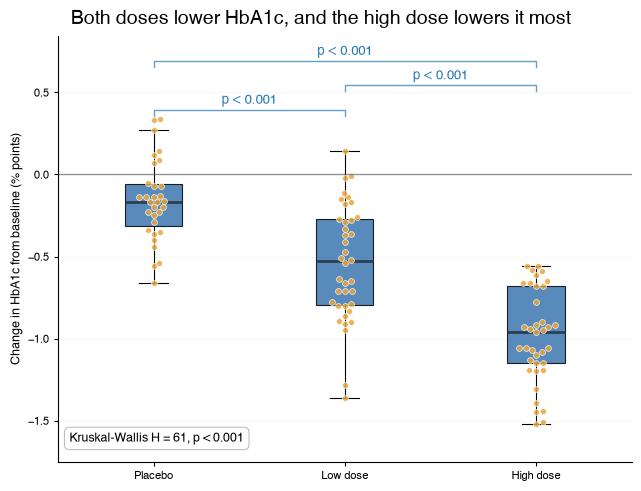

In [4]:
REFERENCE_HLINE = {"plot_hline_color": "#666666", "plot_hline_width": 1}
NOTE_STYLE = {"plot_text_size": 9, "plot_text_valign": "bottom"}


def as_p(pvalue):
    return "p < 0.001" if pvalue < 0.001 else f"p = {pvalue:.2f}"


records = [
    {"label": arm, "value": float(value)} for arm in ARMS for value in change[arm]
]

boxes = BoxPlot(
    records,
    show_outliers=False,
    # one bracket per pairwise test, named by the arms it compares
    brackets=[
        {"from": a, "to": b, "text": as_p(pvalue)}
        for (a, b), pvalue in zip(PAIRS, adjusted)
    ],
    hlines={"y": 0, "style": REFERENCE_HLINE},
    texts={
        "text": f"Kruskal-Wallis H = {omnibus.statistic:.0f}, {as_p(omnibus.pvalue)}",
        "x": 0.02,
        "y": 0.04,
        "coords": "axes",
        "style": NOTE_STYLE,
    },
)
points = SwarmPlot(records)

endpoint_figure = Panel(
    [boxes, points],
    title="Both doses lower HbA1c, and the high dose lowers it most",
    ylabel_left="Change in HbA1c from baseline (% points)",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
endpoint_figure.show()

All three brackets are significant, so the doses differ from placebo and from each other. The points add what the p-values cannot: the placebo arm straddles zero, the low-dose arm sits wholly below it, and the high-dose arm has no subject above −0.5. That ordering, visible without a test, is what the next figure measures.

### How large is the effect, and does it grow with the dose?

A p-value says a difference is unlikely to be an accident; it never says how large the difference is. The size belongs in its own figure with an interval attached, and the interval here comes from a bootstrap: each arm's changes are resampled with replacement a few thousand times, the mean is recorded each time, and the middle 95% of those means is the interval. `bootstrap_ci` in the [statistics utilities](../../how-to-guides/utility/stats/) does this in one call and returns the two bounds.

Three arms with one number and one interval each is a [bar chart](../../how-to-guides/charts/barchart/) with `yerr` on every bar and `show_yerr` to draw it. `yerr` is a distance from the bar's end, not a bound, so the half-width of the interval is what goes in. The bars run downward because the changes are falls, and `show_values` prints each mean at the bar's end, so the figure doubles as the table.

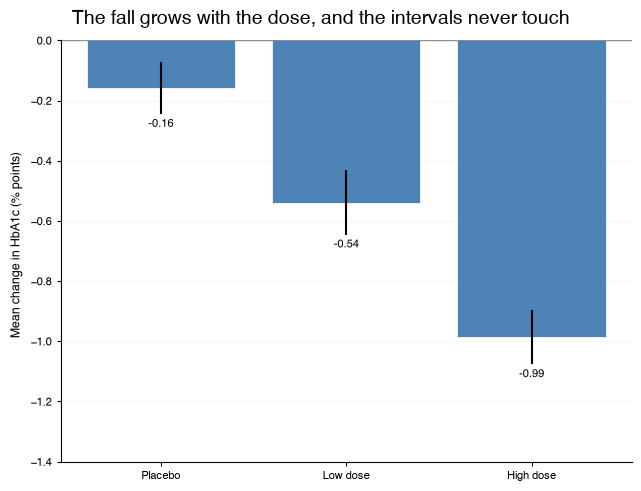

In [5]:
interval = {
    arm: bootstrap_ci(change[arm], n_resamples=4000, seed=20260922) for arm in ARMS
}

dose_figure = BarChart(
    [
        {
            "label": arm,
            "y": float(change[arm].mean()),
            # the half-width of the interval, drawn to each side of the mean
            "yerr": float((interval[arm][1] - interval[arm][0]) / 2),
        }
        for arm in ARMS
    ],
    title="The fall grows with the dose, and the intervals never touch",
    ylabel="Mean change in HbA1c (% points)",
    show_yerr=True,
    show_values=True,
    value_format=VALUE_FORMAT.DECIMAL_2,
    hlines={"y": 0, "style": REFERENCE_HLINE},
    figsize=FIG_SIZE.FULL_MEDIUM,
)
dose_figure.show()

The placebo arm falls by about 0.16 points, which is the drift a trial expects from regression to the mean and closer attention; the low dose adds roughly 0.4 to that and the high dose another 0.45. No interval reaches its neighbour, so the dose-response is monotone and each step is established rather than merely suggested.

### How many subjects reached the target?

A mean change is the trialist's number; the clinician's number is how many subjects ended under the treatment target. Both are read off the distribution of week-12 values, and a [violin plot](../../how-to-guides/charts/violinplot/) shows that distribution's shape per arm: where its bulk sits, and whether a tail reaches across the target line. The target is an `hlines` mark with a `label`, so it enters the legend, and the share of each arm at or under it is a `texts` note at that arm's position, placed in data coordinates.

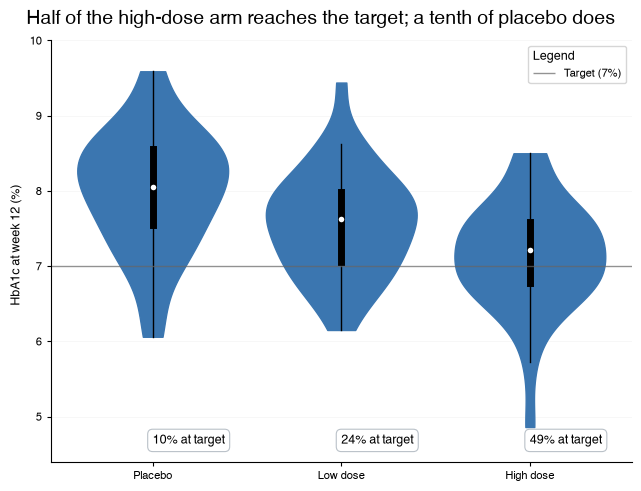

In [6]:
TARGET = 7.0
final = {
    arm: np.array(
        [subject["hba1c"][END] for subject in completed if subject["arm"] == arm]
    )
    for arm in ARMS
}

target_figure = ViolinPlot(
    [{"label": arm, "value": float(value)} for arm in ARMS for value in final[arm]],
    title="Half of the high-dose arm reaches the target; a tenth of placebo does",
    ylabel="HbA1c at week 12 (%)",
    hlines={"y": TARGET, "label": f"Target ({TARGET:.0f}%)", "style": REFERENCE_HLINE},
    # one note per arm, at the arm's category position
    texts=[
        {
            "text": f"{np.mean(final[arm] <= TARGET):.0%} at target",
            "x": position,
            "y": 4.6,
            "style": NOTE_STYLE,
        }
        for position, arm in enumerate(ARMS)
    ],
    ymin=4.4,
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
target_figure.show()

The placebo violin sits almost entirely above the line, the low-dose one is centred a little above it, and the high-dose one is centred on it, so half its subjects are at target. The shape adds a caution the shares do not: the high-dose violin has a long lower tail, which means a few subjects fell well past the target, and a treatment that overshoots is a different clinical question from one that does not.

## Over the twelve weeks

### When did the arms separate?

An endpoint is one visit; the trial had five, and the course between them says when the effect appeared and whether it had finished by the end. A [line chart](../../how-to-guides/charts/linechart/) draws the arm means over the visits, and `show_yerr` turns the `yerr` of each point into a band, here the 95% confidence interval of the mean, so where two bands stop overlapping is roughly where two arms become distinguishable.

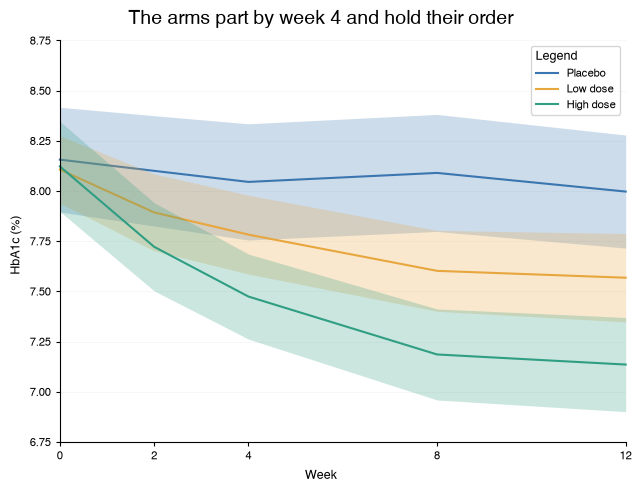

In [7]:
course = {
    arm: np.array(
        [
            [subject["hba1c"][week] for week in WEEKS]
            for subject in completed
            if subject["arm"] == arm
        ]
    )
    for arm in ARMS
}


def visit(week, values):
    """One visit's mean, with the half-width of its 95% interval as the error."""
    half_width = 1.96 * values.std(ddof=1) / np.sqrt(values.size)
    return {"x": week, "y": float(values.mean()), "yerr": float(half_width)}


course_figure = LineChart(
    [
        [visit(week, course[arm][:, index]) for index, week in enumerate(WEEKS)]
        for arm in ARMS
    ],
    title="The arms part by week 4 and hold their order",
    xlabel="Week",
    ylabel="HbA1c (%)",
    subtitle=ARMS,
    show_yerr=True,
    xticks=WEEKS,
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
course_figure.show()

The three lines leave the same point and the high-dose band has cleared the placebo band by week 4; the low-dose band takes until week 8. Both dose curves are still falling at week 12, more slowly than before, so the trial ended before the effect had fully settled; a 24-week extension is the obvious next study, and this figure is the argument for it.

### Did every subject follow the mean?

A mean course can hide a split population: half the arm responding fully and half not at all averages to the same line as everyone responding by half. The check is to draw every subject's own course, one line each, and the mean over them. With more than a hundred lines the figure needs a hierarchy, and `emphasis` supplies it: the subject lines take the `"background"` role, drawn thin and muted with no legend entry, and the three arm means take `"highlight"`, drawn bold and in front. The [line chart](../../how-to-guides/charts/linechart/) is otherwise the same call as above.

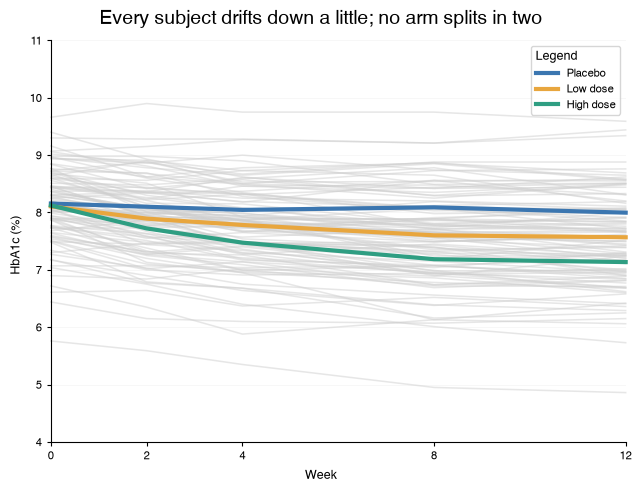

In [8]:
subject_lines = [
    [{"x": week, "y": subject["hba1c"][week]} for week in WEEKS]
    for subject in completed
]
mean_lines = [
    [
        {"x": week, "y": float(course[arm][:, index].mean())}
        for index, week in enumerate(WEEKS)
    ]
    for arm in ARMS
]

LineChart(
    subject_lines + mean_lines,
    title="Every subject drifts down a little; no arm splits in two",
    xlabel="Week",
    ylabel="HbA1c (%)",
    # only the means get a legend entry
    subtitle=[None] * len(subject_lines) + ARMS,
    emphasis=[EMPHASIS.BACKGROUND] * len(subject_lines)
    + [EMPHASIS.HIGHLIGHT] * len(ARMS),
    xticks=WEEKS,
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The grey lines fan across the whole 5 to 10% range, which is the baseline spread, and they run roughly parallel: subjects keep their rank while the arm shifts as a whole. No cluster of lines drops away from its neighbours, so the mean is an honest summary of every arm. When it is not, this figure is the one that shows it.

### Who stayed in the trial?

Every figure so far used the subjects who completed, and a report has to say who did not. The share of each arm still enrolled, week by week, is a step curve: it holds its value until a subject leaves and drops there. A [line chart](../../how-to-guides/charts/linechart/) draws it with `plot_line_drawstyle` set to a stepped style, so the curve falls at the dropout instead of sloping towards it, which a plain line would falsely imply. No subject here is lost for any reason other than leaving, so the curve is one minus the share who left; with censoring, the Kaplan-Meier estimate takes its place and the figure stays the same.

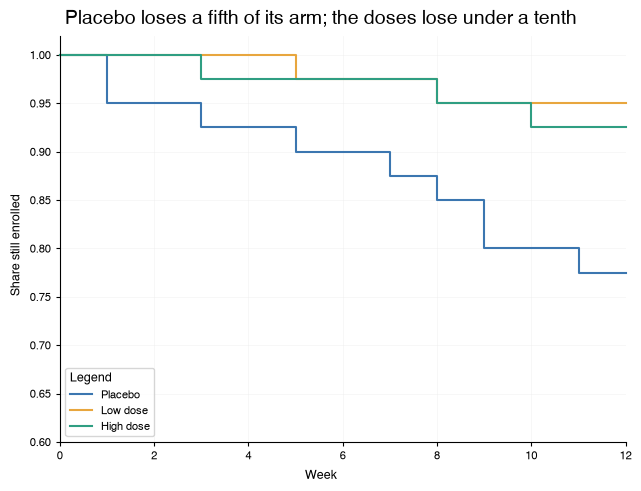

In [9]:
LAST_WEEK = 12


def still_enrolled(arm, week):
    """The share of an arm still in the trial at the start of a week."""
    members = [subject for subject in subjects if subject["arm"] == arm]
    return float(
        np.mean([s["dropout"] is None or s["dropout"] > week for s in members])
    )


retention_figure = LineChart(
    [
        [{"x": week, "y": still_enrolled(arm, week)} for week in range(LAST_WEEK + 1)]
        for arm in ARMS
    ],
    title="Placebo loses a fifth of its arm; the doses lose under a tenth",
    xlabel="Week",
    ylabel="Share still enrolled",
    subtitle=ARMS,
    # the curve holds its level until a subject leaves
    style={"plot_line_drawstyle": LINE_DRAW_STYLE.STEPS_POST},
    ymin=0.6,
    ymax=1.02,
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
retention_figure.show()

Nine placebo subjects left against two and three on the doses, and the placebo curve drops steadily from the first week: subjects who feel no benefit stop coming. That matters for the endpoint figure, which saw only the completers: an arm that loses its non-responders looks better at week 12 than it was. The retention figure is where a reader checks for that, and here the placebo arm thinned while the treated ones did not.

## The wider panel

### Which markers moved with the dose?

A trial measures more than its endpoint, and eight markers in three arms is a 24-cell table that a [heatmap](../../how-to-guides/charts/heatmap/) reads in one look. The cells hold the percent change from baseline, which is signed, so the colormap has to put zero in the middle: `norm=COLOR_NORM.CENTERED` pins zero to the centre of the theme's diverging colormap and runs the same distance each way, so a cell's hue is its direction and its depth is its size. `show_values` prints the numbers in the cells, and `value_format` gives them their sign and unit.

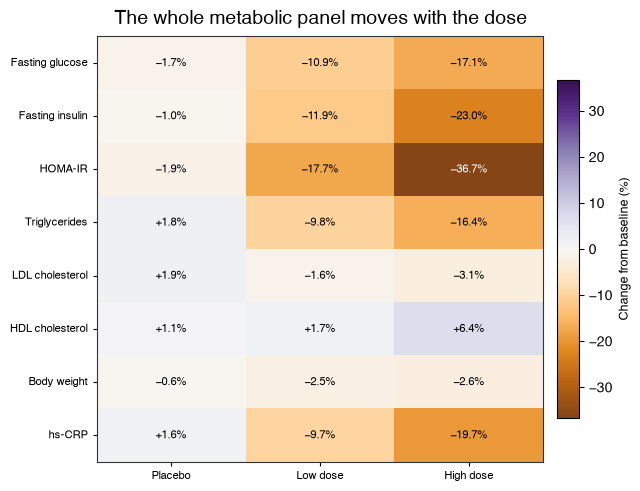

In [10]:
marker_figure = Heatmap(
    {
        "x": ARMS,
        "y": MARKERS,
        "z": [[marker_change[marker][arm] for arm in ARMS] for marker in MARKERS],
    },
    title="The whole metabolic panel moves with the dose",
    # zero in the middle of the diverging colormap, equal reach each way
    norm=COLOR_NORM.CENTERED,
    show_values=True,
    show_colorbars=True,
    value_format="{x:+.1f}%",
    colorbar={"label": "Change from baseline (%)"},
    figsize=FIG_SIZE.FULL_MEDIUM,
)
marker_figure.show()

The placebo column is near white throughout, the columns darken left to right, and the insulin-resistance rows darken most: the compound is doing what its mechanism predicts. The one cell running the other way is HDL cholesterol, which rises, and a rise in HDL is a favourable change; a diverging colormap makes that opposite sign visible where a single-hue one would have hidden it as a light cell.

### Where are the safety signals?

The safety labs are read differently from the efficacy markers: the safety question is whether any lab moved at all, per arm, from a baseline that should have been the same in every arm. Two values per arm and lab (baseline and week 12) is a [dumbbell chart](../../how-to-guides/charts/dumbbellchart/): a dot at each, a connector between, and `show_values=True, value_kind="delta"` printing the change at the connector. The labs live on four different scales, so `subplots=True` gives each its own axes, and `show_direction` draws an arrow from baseline to week 12 so the direction reads without a legend.

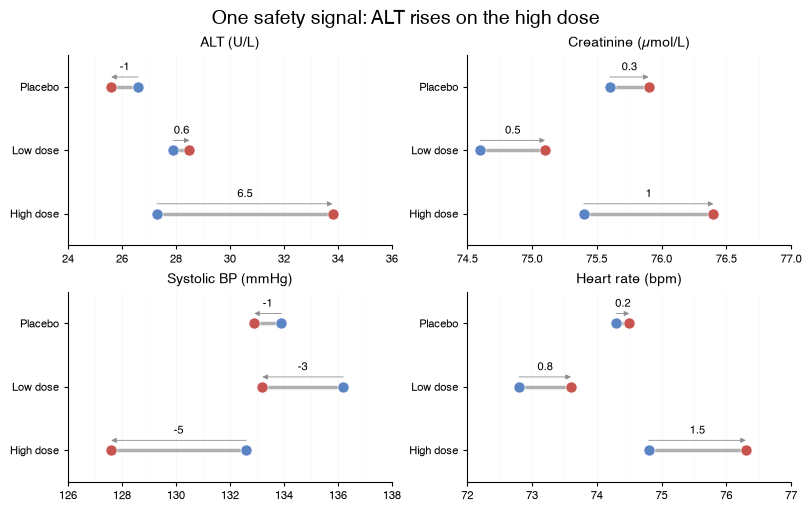

In [11]:
DumbbellChart(
    [
        [
            {
                "label": arm,
                "start": safety[arm][lab]["baseline"],
                "end": safety[arm][lab]["week 12"],
            }
            for arm in ARMS
        ]
        for lab in SAFETY
    ],
    title="One safety signal: ALT rises on the high dose",
    start_name="Baseline",
    end_name="Week 12",
    subtitle=SAFETY,
    show_values=True, value_kind="delta",
    show_direction=True,
    subplots=True,
    max_cols=2,
    figsize=(8.0, 5.0),
).show()

Three of the four panels show connectors a unit or two long in every arm, which is noise. The fourth does not: ALT, a liver enzyme, rises by about 6 U/L on the high dose and by nothing elsewhere. That is a signal, and a signal in an arm mean raises one more question before it goes in the report.

### Is the signal an arm or a few subjects?

A mean rise of 6 U/L is either every high-dose subject rising a little or a few rising a lot, and the two are different findings: one is a class effect, the other is a handful of individuals to follow up. Only the subjects themselves can answer it, so a [swarm plot](../../how-to-guides/charts/swarmplot/) draws every subject's ALT change at its arm. A record's own `emphasis` role marks the ones over the flagging threshold, which is an `hlines` mark with a `label` so the legend names it.

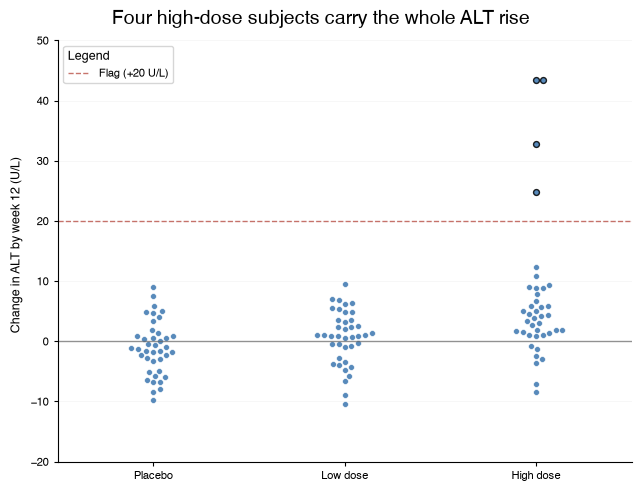

In [12]:
ALT_FLAG = 20
FLAG_HLINE = {"plot_hline_color": "#b03a2e", "plot_hline_style": "--"}

alt_figure = SwarmPlot(
    [
        {
            "label": subject["arm"],
            "value": subject["alt_change"],
            # the record's own role wins over its group's
            "emphasis": (
                EMPHASIS.HIGHLIGHT if subject["alt_change"] > ALT_FLAG else None
            ),
        }
        for subject in subjects
    ],
    title="Four high-dose subjects carry the whole ALT rise",
    ylabel="Change in ALT by week 12 (U/L)",
    hlines=[
        {"y": 0, "style": REFERENCE_HLINE},
        {"y": ALT_FLAG, "label": f"Flag (+{ALT_FLAG} U/L)", "style": FLAG_HLINE},
    ],
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
alt_figure.show()

The three swarms sit on the zero line with the same spread, and four outlined points stand alone above the flag. The arm mean was those four subjects, not the arm: the rest of the high-dose swarm is indistinguishable from placebo. The report's sentence changes accordingly, from "ALT rose on the high dose" to "four of forty high-dose subjects had a flagged ALT rise", and the figure is the evidence for the second version.

## The report figure

A paper has room for one figure, not nine. The four that carry the argument (the arms differ, here is when they parted, here is the rest of the panel, and here is who stayed) go into one panel with [Grid](../../how-to-guides/utility/grid/), which takes the figures already drawn above and redraws them into its cells. Nested lists are the layout: one inner list per row. The endpoint cell is itself a `Panel`, and the grid takes it like any other figure.

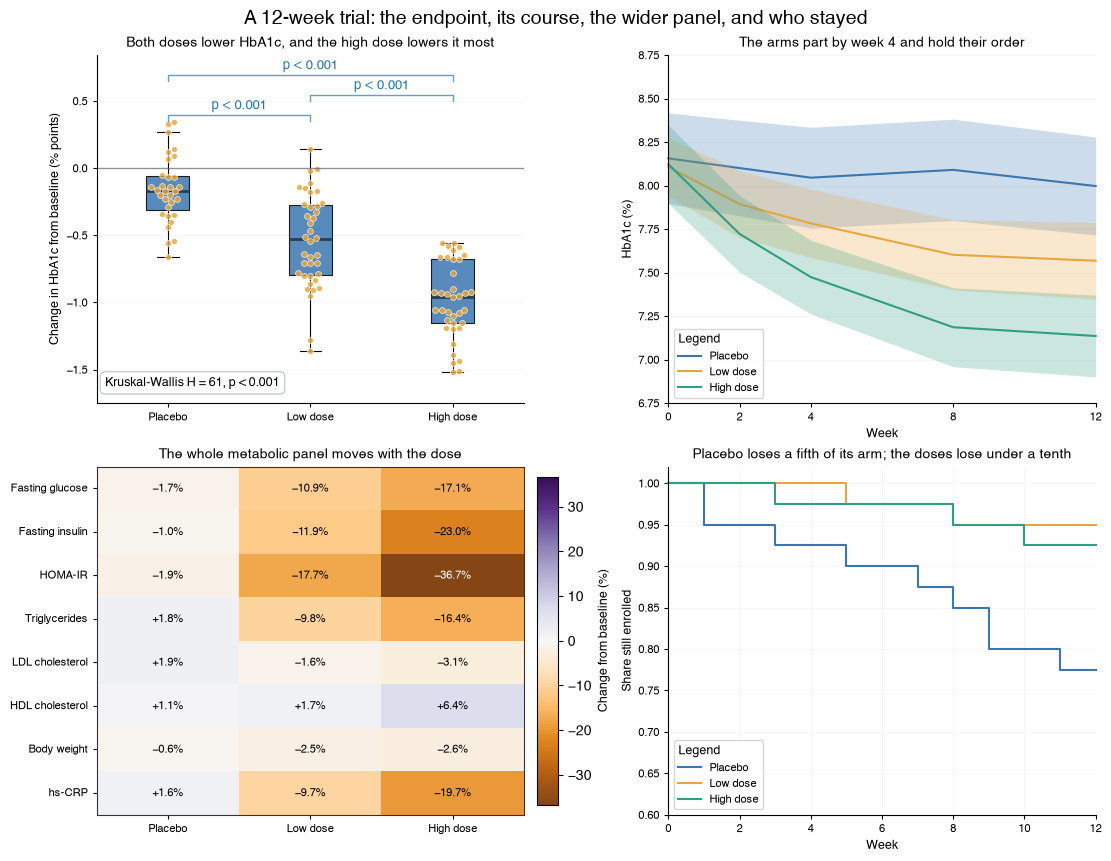

In [13]:
Grid(
    [
        [endpoint_figure, course_figure],
        [marker_figure, retention_figure],
    ],
    title="A 12-week trial: the endpoint, its course, the wider panel, and who stayed",
    figsize=(11.0, 8.5),
).show()

Every figure on this page is one call to a chart function over a list of dicts, and every number in them comes from a `scipy.stats` call or a few lines of numpy written out in the cell above it. To adapt any of them, open the guide it links to and read the parameter that does the job; the [annotations guide](../../how-to-guides/utility/annotations/) covers the brackets, reference lines and notes the figures share. The charts index lists them all: [Charts](../../how-to-guides/charts/).